In [75]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

In [57]:
# Dummy Dataset for our model
df = pd.DataFrame(
    {
        'x1' :  [5,2,1,9,3],
        'x2' :  [7,9,3,8,7],
        'y'  :  [1,0,1,0,0]
    }   
)

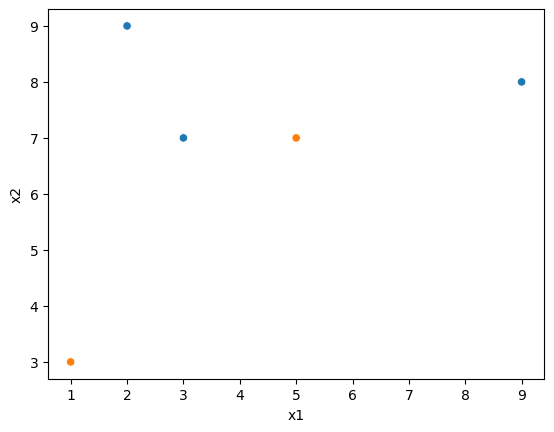

In [80]:
sns.scatterplot(    
                    data = df,
                    x = 'x1' , 
                    y = 'x2',
                    hue = 'y',
                    legend = False
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [59]:
df

,x1,x2,y
0,5,7,1
1,2,9,0
2,1,3,1
3,9,8,0
4,3,7,0


In [60]:
# Weights = 1/len(df) or No of rows
df['weights'] = 1/len(df)

In [61]:
df

,x1,x2,y,weights
0,5,7,1,0.2
1,2,9,0,0.2
2,1,3,1,0.2
3,9,8,0,0.2
4,3,7,0,0.2


In [62]:
X , y  =  df.iloc[:,:2].values , df.iloc[:,-2].values

In [63]:
# Now I will create a weak learner Decision Tree model with max_depth = 1 that willm act as a stump.

dtr1 = DecisionTreeClassifier(max_depth=1)

In [64]:
dtr1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [65]:
df['y_pred'] = dtr1.predict(X)

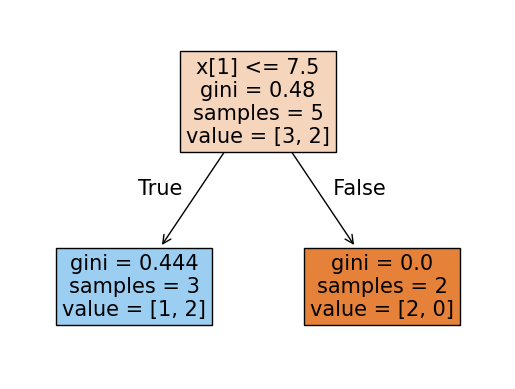

In [73]:
plot_tree(
            dtr1 ,
            filled = True,
            fontsize = 15
        )
plt.show()

In [ ]:
df

,x1,x2,y,weights,y_pred
0,5,7,1,0.2,1
1,2,9,0,0.2,0
2,1,3,1,0.2,1
3,9,8,0,0.2,0
4,3,7,0,0.2,1


In [ ]:
# Missclassifed points :  (3,7)
# Model Weight : alpha1 = 0.5*ln*(1-sum_of_error_weights)/(sum_of_error_weights) 
alpha1 = 0.5*np.log((1-0.2)/(0.2)) # 0.2 is the weight of misclassifed point (3,7)

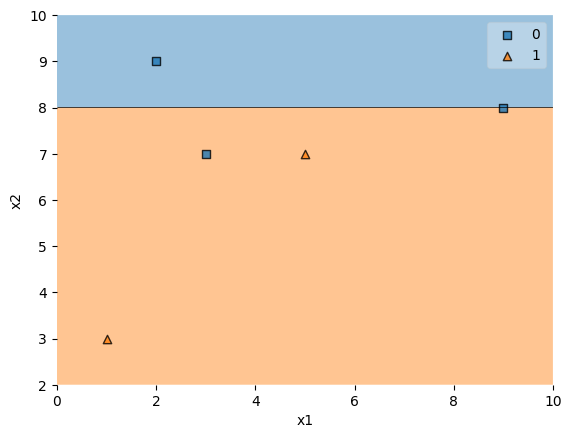

In [79]:
plot_decision_regions(  
                        X,
                        y,
                        dtr1)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()